In [1]:
import pandas as pd
import coiled
import yaml
import geodatasets
import geopandas as gpd
import math
import rasterio
import os
import openpyxl
import pygwalker as pyg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import re
import sys
import textwrap
from shapely.geometry import Point
from datetime import datetime
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import blended_transform_factory
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from io import BytesIO
from IPython.display import Image, display as ipy_display
from rasterio.windows import Window
from tqdm.auto import tqdm
from dask.distributed import Client, as_completed

In [2]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn
from src.utilities import universal_utilities as uu
from src.utilities.create_cluster import create_cluster as cc_create_cluster

now = datetime.now()
today = now.strftime("%Y%m%d")

pd.set_option('display.max_columns', None)

LULUCF_zonal_stats_folder = Path(f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v{cn.LULUCF_model_version_underscore}__veg_v{cn.veg_model_version_underscore}__minsoil_v{cn.SOC_model_version_underscore}__orgsoil_v{cn.organic_soil_model_version_underscore}/')

In [3]:
# %%time

# ### Global cumulative flux curves from 1x1 deg per-ha gross emissions and gross removals chunks — Coiled parallel version
# ### Histogram approach: memory-efficient, scalable to global
# ### Creates two panels: (1) combined global curves, (2) individual chunk curves + mean overlaid
# ### Per Claude session Lorenz curves for LULUCF emissions/removals and 'Lorenz curves for LULUCF emissions/removals, pt2'

# # ── Coiled configuration ───────────────────────────────────────────────────
# CLUSTER_NAME  = 'lorenz_curves'
# N_WORKERS     = 100
# WORKER_MEMORY = 8       # GiB — sufficient for per-chunk raster reads
# RUN_LOCAL     = True   # True: run serially without Coiled (for testing)
# BATCH_SIZE    = 3000     # chunks per gather batch; bounds memory on scheduler

# # ── Analysis configuration ─────────────────────────────────────────────────

# PERIOD = "avg_2016_2024"

# SINGLE_CHUNK  = None
# # BOUNDING_BOX  = [10, 49, 11, 50]
# # BOUNDING_BOX  = [10, 40, 20, 50]
# BOUNDING_BOX  = [-85, 33, -82, 36]
# # BOUNDING_BOX  = [10, 47, 13, 50]
# # BOUNDING_BOX  = [0, -10, 15, 0]
# # BOUNDING_BOX = None
# # SHAPEFILE_URI = "s3://gfw2-data/climate/AFOLU_flux_model/fishnet_1x1deg/20250429/fishnet_GADM41_1x1deg__spatial_join_intersect__20250428__center_in.shp"
# SHAPEFILE_URI = None
# FIRST_CHUNKS  = None

# N_BINS           = 10_000
# INTENSITY_MIN    = 1e-6     # MgCO2e/ha/yr
# INTENSITY_MAX    = 1e5      # MgCO2e/ha/yr
# MIN_VALID_PIXELS = 1000
# N_PLOT_POINTS    = 200
# INDIVIDUAL_ALPHA = 0.05

# BASE     = ("s3://gfw2-data/climate/AFOLU_flux_model/LULUCF/outputs_LULUCF_totals/LULUCF_version_1_0_0_standard__global__veg_v1_0_5__org_soil_v1_0_1__min_soil_v1_0_1")
# EMIS_DIR = (f"{BASE}/LULUCF_gross_emissions__all_C_pools__all_gases__MgCO2e/annual_intervals/avg_2016_2024/_ha_yr/4000_pixels/20260614")
# REMV_DIR = (f"{BASE}/LULUCF_gross_removals__all_C_pools__MgCO2/annual_intervals/avg_2016_2024/_ha_yr/4000_pixels/20260614")

# # ── Build chunk list ───────────────────────────────────────────────────────
# if SINGLE_CHUNK is not None:
#     chunk_list = [SINGLE_CHUNK]
#     area_label = f"chunk {SINGLE_CHUNK}"
# elif BOUNDING_BOX is not None:
#     chunk_list = uu.get_chunk_bounds_from_bounding_box(BOUNDING_BOX, chunk_size=1.0)
#     area_label = f"bbox W={BOUNDING_BOX[0]} S={BOUNDING_BOX[1]} E={BOUNDING_BOX[2]} N={BOUNDING_BOX[3]}"
# elif SHAPEFILE_URI is not None:
#     fishnet_iso_df = uu.fishnet_with_GADM_iso(SHAPEFILE_URI)
#     if FIRST_CHUNKS:
#         fishnet_iso_df = fishnet_iso_df[:FIRST_CHUNKS]
#     chunk_list = fishnet_iso_df['chunk_id'].apply(uu.process_chunk_id).tolist()
#     area_label = SHAPEFILE_URI.split('/')[-1]
# else:
#     raise ValueError("Set one of SINGLE_CHUNK, BOUNDING_BOX, or SHAPEFILE_URI")

# print(f"Chunks to process: {len(chunk_list):,}")

# # ── Worker function ────────────────────────────────────────────────────────
# def process_chunk_lorenz(bounds, period, emis_dir, remv_dir,
#                           n_bins, intensity_min, intensity_max,
#                           min_valid_pixels, n_plot_points):
#     """
#     Processes one 1x1 deg chunk on a Coiled worker.
#     Returns partial histogram accumulators and a downsampled cumulative flux curve.
#     All imports are local so the function is self-contained on the worker.
#     bin_edges reconstructed from scalars to avoid serialising a large array
#     for every task submission.
#     Lorenz sort is descending (highest intensity first) → curves go up-then-right.
#     """
#     import numpy as np
#     import rasterio
#     from src.utilities import universal_utilities as uu

#     w, s, e, n = bounds
#     tile_id    = uu.xy_to_tile_id(w, n)
#     bounds_str = uu.boundstr(bounds)
#     emis_path  = (f"{emis_dir}/{tile_id}__{bounds_str}__"
#                   f"LULUCF_gross_emissions__all_C_pools__all_gases__MgCO2e_ha_yr_{period}.tif")
#     remv_path  = (f"{remv_dir}/{tile_id}__{bounds_str}__"
#                   f"LULUCF_gross_removals__all_C_pools__MgCO2_ha_yr_{period}.tif")

#     bin_edges = np.logspace(np.log10(intensity_min), np.log10(intensity_max), n_bins + 1)
#     x_uniform = np.linspace(0, 1, n_plot_points)

#     def pixel_area_ha_by_row(src):
#         t           = src.transform
#         row_idx     = np.arange(src.height)
#         lat_centers = t.f + (row_idx + 0.5) * t.e
#         d_lat_rad   = abs(t.e) * np.pi / 180
#         d_lon_rad   = abs(t.a) * np.pi / 180
#         area_km2    = 6371.0**2 * d_lat_rad * d_lon_rad * np.cos(np.deg2rad(lat_centers))
#         return area_km2 * 100

#     def lorenz_from_histogram(bin_area, bin_flux):
#         """Descending sort → curves go up-then-right, above diagonal."""
#         occupied = (bin_area > 0) | (bin_flux > 0)
#         if not occupied.any():
#             return None, None
#         cum_area = np.concatenate([[0.0], np.cumsum(bin_area[occupied][::-1])])
#         cum_flux = np.concatenate([[0.0], np.cumsum(bin_flux[occupied][::-1])])
#         if cum_area[-1] == 0 or cum_flux[-1] == 0:
#             return None, None
#         return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

#     result = {
#         'emis_bin_area': np.zeros(n_bins),
#         'emis_bin_flux': np.zeros(n_bins),
#         'remv_bin_area': np.zeros(n_bins),
#         'remv_bin_flux': np.zeros(n_bins),
#         'n_emis_valid' : 0,
#         'n_remv_valid' : 0,
#         'chunk_emis_y' : None,
#         'chunk_remv_y' : None,
#         'status'       : 'ok',
#     }

#     try:
#         with rasterio.open(emis_path) as src:
#             emis_grid = src.read(1).astype(np.float64)
#             areas_1d  = pixel_area_ha_by_row(src)
#             area_grid = np.broadcast_to(areas_1d[:, np.newaxis], emis_grid.shape)
#         with rasterio.open(remv_path) as src:
#             remv_grid = src.read(1).astype(np.float64)
#     except Exception as ex:
#         result['status'] = f'missing: {ex}'
#         return result

#     # Emissions
#     emis_mask = emis_grid > 0
#     n_emis    = int(emis_mask.sum())
#     result['n_emis_valid'] = n_emis
#     if n_emis > 0:
#         e_ha      = emis_grid[emis_mask]
#         e_ha_area = area_grid[emis_mask]
#         e_flux    = e_ha * e_ha_area
#         bidx      = np.clip(
#             np.searchsorted(bin_edges, e_ha, side='right') - 1, 0, n_bins - 1
#         )
#         result['emis_bin_area'] += np.bincount(bidx, weights=e_ha_area, minlength=n_bins)
#         result['emis_bin_flux'] += np.bincount(bidx, weights=e_flux,    minlength=n_bins)
#         if n_emis >= min_valid_pixels:
#             cx, cy = lorenz_from_histogram(result['emis_bin_area'], result['emis_bin_flux'])
#             if cx is not None:
#                 result['chunk_emis_y'] = np.interp(x_uniform, cx, cy)

#     # Removals
#     remv_mask = remv_grid < 0
#     n_remv    = int(remv_mask.sum())
#     result['n_remv_valid'] = n_remv
#     if n_remv > 0:
#         r_ha      = np.abs(remv_grid[remv_mask])
#         r_ha_area = area_grid[remv_mask]
#         r_flux    = r_ha * r_ha_area
#         bidx      = np.clip(
#             np.searchsorted(bin_edges, r_ha, side='right') - 1, 0, n_bins - 1
#         )
#         result['remv_bin_area'] += np.bincount(bidx, weights=r_ha_area, minlength=n_bins)
#         result['remv_bin_flux'] += np.bincount(bidx, weights=r_flux,    minlength=n_bins)
#         if n_remv >= min_valid_pixels:
#             cx, cy = lorenz_from_histogram(result['remv_bin_area'], result['remv_bin_flux'])
#             if cx is not None:
#                 result['chunk_remv_y'] = np.interp(x_uniform, cx, cy)

#     return result

# # ── Connect to cluster (or fall back to local) ─────────────────────────────
# cluster, client, run_local = uu.connect_to_Coiled_cluster(
#     CLUSTER_NAME, RUN_LOCAL, fallback_to_local_on_failure=False
# )

# # # If no running cluster found, create one
# # if cluster is None and not RUN_LOCAL:
# #     print(f"No running cluster '{CLUSTER_NAME}' found — creating one...")
# #     cluster = cc_create_cluster(CLUSTER_NAME, N_WORKERS, WORKER_MEMORY, threads_per_worker=1)
# #     client  = Client(cluster)
# #     print(f"Cluster ready: {cluster.dashboard_link}")

# # ── Global accumulators ────────────────────────────────────────────────────
# emis_bin_area     = np.zeros(N_BINS, dtype=np.float64)
# emis_bin_flux     = np.zeros(N_BINS, dtype=np.float64)
# remv_bin_area     = np.zeros(N_BINS, dtype=np.float64)
# remv_bin_flux     = np.zeros(N_BINS, dtype=np.float64)
# chunk_emis_curves = []
# chunk_remv_curves = []
# x_uniform         = np.linspace(0, 1, N_PLOT_POINTS)
# n_ok              = 0
# n_missing         = 0
# n_skipped_emis    = 0
# n_skipped_remv    = 0

# # ── Shared task kwargs ─────────────────────────────────────────────────────
# task_kwargs = dict(
#     period           = PERIOD,
#     emis_dir         = EMIS_DIR,
#     remv_dir         = REMV_DIR,
#     n_bins           = N_BINS,
#     intensity_min    = INTENSITY_MIN,
#     intensity_max    = INTENSITY_MAX,
#     min_valid_pixels = MIN_VALID_PIXELS,
#     n_plot_points    = N_PLOT_POINTS,
# )

# def _aggregate(result):
#     """Aggregate one worker result into global accumulators."""
#     global n_ok, n_missing, n_skipped_emis, n_skipped_remv
#     global emis_bin_area, emis_bin_flux, remv_bin_area, remv_bin_flux
#     global chunk_emis_curves, chunk_remv_curves
#     if result['status'] != 'ok':
#         n_missing += 1
#         return
#     emis_bin_area += result['emis_bin_area']
#     emis_bin_flux += result['emis_bin_flux']
#     remv_bin_area += result['remv_bin_area']
#     remv_bin_flux += result['remv_bin_flux']
#     if result['chunk_emis_y'] is not None:
#         chunk_emis_curves.append(result['chunk_emis_y'])
#     else:
#         n_skipped_emis += 1
#     if result['chunk_remv_y'] is not None:
#         chunk_remv_curves.append(result['chunk_remv_y'])
#     else:
#         n_skipped_remv += 1
#     n_ok += 1

# # ── Process: Coiled (parallel) or local (serial) ───────────────────────────
# chunk_batches = [chunk_list[i:i + BATCH_SIZE]
#                  for i in range(0, len(chunk_list), BATCH_SIZE)]

# if client is not None:
#     print(f"Submitting {len(chunk_list):,} chunks in "
#           f"{len(chunk_batches)} batches of {BATCH_SIZE}...")

#     for i, batch in enumerate(chunk_batches):
#         futures = [
#             client.submit(
#                 process_chunk_lorenz,
#                 bounds,
#                 **task_kwargs,
#                 key=f"lorenz-{int(bounds[0])}_{int(bounds[1])}_{int(bounds[2])}_{int(bounds[3])}"
#             )
#             for bounds in batch
#         ]
#         for future in tqdm(
#             as_completed(futures),
#             total=len(futures),
#             desc=f"Batch {i+1}/{len(chunk_batches)}"
#         ):
#             try:
#                 _aggregate(future.result())
#             except Exception as ex:
#                 n_missing += 1
#                 print(f"  Future failed: {ex}")

# else:
#     print("Running locally (no Coiled cluster)...")
#     for bounds in tqdm(chunk_list, desc=f"Processing chunks"):
#         result = process_chunk_lorenz(bounds, **task_kwargs)
#         _aggregate(result)

# print(f"\nDone — processed: {n_ok:,}  |  missing/skipped: {n_missing:,}")
# print(f"Chunks below {MIN_VALID_PIXELS} pixel threshold — "
#       f"emissions: {n_skipped_emis:,}  removals: {n_skipped_remv:,}")

# # ── Reconstruct cumulative flux curves from histogram (descending intensity) ──
# def lorenz_from_histogram(bin_area, bin_flux):
#     """Descending sort (highest intensity first) → curves go up-then-right,
#     above the diagonal. Returns (cum_area_frac, cum_flux_frac), both 0→1."""
#     occupied = (bin_area > 0) | (bin_flux > 0)
#     cum_area = np.concatenate([[0.0], np.cumsum(bin_area[occupied][::-1])])
#     cum_flux = np.concatenate([[0.0], np.cumsum(bin_flux[occupied][::-1])])
#     return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

# def gini(x, y):
#     """For a curve above the diagonal (descending sort): Gini = 2*trapz(y,x) - 1."""
#     return 2.0 * np.trapezoid(y, x) - 1.0

# emis_x, emis_y = lorenz_from_histogram(emis_bin_area, emis_bin_flux)
# remv_x,  remv_y = lorenz_from_histogram(remv_bin_area,  remv_bin_flux)

# emis_area_Mha = emis_bin_area.sum() / 1e6
# remv_area_Mha = remv_bin_area.sum() / 1e6
# emis_flux_Gt  = emis_bin_flux.sum() / 1e9
# remv_flux_Gt  = remv_bin_flux.sum() / 1e9

# # ── Plot ───────────────────────────────────────────────────────────────────
# pct_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 21))

# # ── Panel 1: combined global curves ───────────────────────────────────────
# ax1.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Line of equality')
# ax1.plot(remv_x, remv_y, color='steelblue', lw=2,
#          label=f'Gross removals') #   (Gini = {gini(remv_x, remv_y):.3f})')
# ax1.plot(emis_x, emis_y, color='firebrick', lw=2,
#          label=f'Gross emissions') #  (Gini = {gini(emis_x, emis_y):.3f})')

# # 80% emissions reference lines
# x_80  = np.interp(0.80, emis_y, emis_x)
# ax1.axvline(x=x_80,  ymin=0, ymax=0.80, color='firebrick',  lw=0.8, ls='--')
# ax1.axhline(y=0.80,  xmin=0, xmax=x_80, color='firebrick',  lw=0.8, ls='--')

# # 80% removals reference lines
# x_80r = np.interp(0.80, remv_y, remv_x)
# ax1.axvline(x=x_80r, ymin=0, ymax=0.80, color='steelblue', lw=0.8, ls='--')
# ax1.axhline(y=0.80,  xmin=0, xmax=x_80r, color='steelblue', lw=0.8, ls='--')

# # 50% emissions reference lines
# x_50  = np.interp(0.50, emis_y, emis_x)
# ax1.axvline(x=x_50,  ymin=0, ymax=0.50, color='firebrick',  lw=0.8, ls='--')
# ax1.axhline(y=0.50,  xmin=0, xmax=x_50, color='firebrick',  lw=0.8, ls='--')

# # 50% removals reference lines
# x_50r = np.interp(0.50, remv_y, remv_x)
# ax1.axvline(x=x_50r, ymin=0, ymax=0.50, color='steelblue', lw=0.8, ls='--')
# ax1.axhline(y=0.50,  xmin=0, xmax=x_50r, color='steelblue', lw=0.8, ls='--')

# ax1.set_xlabel('Cumulative share of land area', fontsize=12)
# ax1.set_title(
#     f'Cumulative flux curves — LULUCF gross emissions & removals\n{area_label}',
#     fontsize=11
# )
# ax1.legend(fontsize=11, loc='lower right')
# ax1.set_xlim(0, 1)
# ax1.set_ylim(0, 1)
# ax1.set_box_aspect(1)

# ax1_right = ax1.twinx()
# ax1_top   = ax1.twiny()
# ax1.set_xticks(pct_ticks)
# ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
# ax1.set_yticks(pct_ticks)
# ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
# ax1_right.set_ylim(0, 1)
# ax1_right.set_yticks(pct_ticks)
# ax1_right.set_yticklabels(
#     [f"+{v * emis_flux_Gt:.4f} emis\n{-v * remv_flux_Gt:.4f} remov" for v in pct_ticks],
#     fontsize=8
# )
# ax1_right.set_ylabel('Cumulative flux (GtCO2e/yr)', fontsize=9)
# ax1_right.tick_params(axis='y', length=0)
# ax1_top.set_xlim(0, 1)
# ax1_top.set_xticks(pct_ticks)
# ax1_top.set_xticklabels(
#     [f"{v * emis_area_Mha:.2f} emis\n{v * remv_area_Mha:.2f} remov" for v in pct_ticks],
#     fontsize=8
# )
# ax1_top.set_xlabel('Cumulative area (Mha)', fontsize=9)
# ax1_top.tick_params(axis='x', length=0)

# # ── Panel 2: individual chunk curves + mean overlaid ──────────────────────
# if chunk_emis_curves:
#     segs = [np.column_stack([x_uniform, y]) for y in chunk_emis_curves]
#     ax2.add_collection(LineCollection(
#         segs, color='firebrick', alpha=INDIVIDUAL_ALPHA, linewidth=0.5
#     ))
# if chunk_remv_curves:
#     segs = [np.column_stack([x_uniform, y]) for y in chunk_remv_curves]
#     ax2.add_collection(LineCollection(
#         segs, color='steelblue', alpha=INDIVIDUAL_ALPHA, linewidth=0.5
#     ))
# ax2.plot([0, 1], [0, 1], 'k--', lw=1.2)
# ax2.plot(remv_x, remv_y, color='steelblue', lw=2,
#          label=f'Mean removals') #   (Gini = {gini(remv_x, remv_y):.3f})')
# ax2.plot(emis_x, emis_y, color='firebrick', lw=2,
#          label=f'Mean emissions') #  (Gini = {gini(emis_x, emis_y):.3f})')
# ax2.legend(
#     handles=[
#         ax2.get_lines()[1],
#         ax2.get_lines()[2],
#         Line2D([0], [0], color='steelblue', alpha=0.4, lw=1,
#                label=f'Individual chunk removals ({len(chunk_remv_curves):,} chunks)'),
#         Line2D([0], [0], color='firebrick',  alpha=0.4, lw=1,
#                label=f'Individual chunk emissions ({len(chunk_emis_curves):,} chunks)'),
#     ],
#     fontsize=10, loc='lower right'
# )
# ax2.set_xlabel('Cumulative share of land area', fontsize=12)
# ax2.set_ylabel('Cumulative share of gross flux', fontsize=12)
# ax2.set_title(
#     f'Individual chunk cumulative flux curves with mean overlaid\n{area_label}',
#     fontsize=11
# )
# ax2.set_xlim(0, 1)
# ax2.set_ylim(0, 1)
# ax2.set_xticks(pct_ticks)
# ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
# ax2.set_yticks(pct_ticks)
# ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
# ax2.set_box_aspect(1)


# # ── Panel 3: percentile envelope around mean curves ────────────────────────
# if chunk_emis_curves:
#     emis_arr = np.array(chunk_emis_curves)   # (n_chunks, N_PLOT_POINTS)
#     emis_p10 = np.percentile(emis_arr, 10, axis=0)
#     emis_p90 = np.percentile(emis_arr, 90, axis=0)
#     ax3.fill_between(x_uniform, emis_p10, emis_p90,
#                      color='firebrick', alpha=0.2, label='Emissions 10th–90th pct')

# if chunk_remv_curves:
#     remv_arr = np.array(chunk_remv_curves)
#     remv_p10 = np.percentile(remv_arr, 10, axis=0)
#     remv_p90 = np.percentile(remv_arr, 90, axis=0)
#     ax3.fill_between(x_uniform, remv_p10, remv_p90,
#                      color='steelblue', alpha=0.2, label='Removals 10th–90th pct')

# ax3.plot([0, 1], [0, 1], 'k--', lw=1.2)
# ax3.plot(remv_x, remv_y, color='steelblue', lw=2, label='Mean removals')
# ax3.plot(emis_x, emis_y, color='firebrick',  lw=2, label='Mean emissions')
# ax3.legend(fontsize=10, loc='lower right')
# ax3.set_xlabel('Cumulative share of land area', fontsize=12)
# ax3.set_ylabel('Cumulative share of gross flux', fontsize=12)
# ax3.set_title(
#     f'Cumulative flux curves — 10th–90th percentile envelope\n{area_label}',
#     fontsize=11
# )
# ax3.set_xlim(0, 1)
# ax3.set_ylim(0, 1)
# ax3.set_xticks(pct_ticks)
# ax3.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
# ax3.set_yticks(pct_ticks)
# ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
# ax3.set_box_aspect(1)


# # ── Validation summary ─────────────────────────────────────────────────────
# print("=" * 57)
# print("VALIDATION SUMMARY")
# print("=" * 57)
# print(f"Chunks processed : {n_ok:,}  |  missing: {n_missing:,}")
# print(f"Histogram bins   : {N_BINS:,}  (log {INTENSITY_MIN:.0e}–{INTENSITY_MAX:.0e} MgCO2e/ha/yr)")
# print(f"Min valid pixels : {MIN_VALID_PIXELS:,}")
# print(f"Chunks in individual curves — emissions: {len(chunk_emis_curves):,}  "
#       f"removals: {len(chunk_remv_curves):,}")

# print(f"\nLand area covered:")
# print(f"  Emitting land         : {emis_area_Mha:>10.2f} Mha")
# print(f"  Removing land         : {remv_area_Mha:>10.2f} Mha")

# print(f"\nTotal fluxes  ← compare against known model output:")
# print(f"  Gross emissions       : +{1000*emis_flux_Gt:>10.5f} MtCO2e/yr")
# print(f"  Gross removals        : -{1000*remv_flux_Gt:>10.5f} MtCO2e/yr")
# print(f"  Gross emissions       : +{emis_flux_Gt:>10.5f} GtCO2e/yr")
# print(f"  Gross removals        : -{remv_flux_Gt:>10.5f} GtCO2e/yr")
# print(f"  Net (emis − remv)     : {emis_flux_Gt - remv_flux_Gt:>+11.5f} GtCO2e/yr")

# print(f"\nConcentration — emissions (total: {emis_area_Mha:.2f} Mha, +{emis_flux_Gt:.5f} GtCO2e/yr):")
# for pct in [10, 25, 50]:
#     idx       = np.searchsorted(emis_x, pct / 100)
#     flux_frac = emis_y[idx]
#     print(f"  Top {pct:2d}% most intensive ({pct/100 * emis_area_Mha:.2f} Mha) → "
#           f"{100*flux_frac:.1f}% of gross emissions (+{flux_frac * emis_flux_Gt:.5f} GtCO2e/yr)")

# print(f"\nConcentration — removals (total: {remv_area_Mha:.2f} Mha, -{remv_flux_Gt:.5f} GtCO2e/yr):")
# for pct in [10, 25, 50]:
#     idx       = np.searchsorted(remv_x, pct / 100)
#     flux_frac = remv_y[idx]
#     print(f"  Top {pct:2d}% most intensive ({pct/100 * remv_area_Mha:.2f} Mha) → "
#           f"{100*flux_frac:.1f}% of gross removals (-{flux_frac * remv_flux_Gt:.5f} GtCO2e/yr)")

# print(f"\nGini coefficients:")
# print(f"  Gross emissions       : {gini(emis_x, emis_y):.4f}")
# print(f"  Gross removals        : {gini(remv_x, remv_y):.4f}")

# print(f"\nCurve endpoint check (should both be exactly 1.0):")
# print(f"  Emissions             : x={emis_x[-1]:.6f},  y={emis_y[-1]:.6f}")
# print(f"  Removals              : x={remv_x[-1]:.6f},  y={remv_y[-1]:.6f}")

# # # ── Shut down cluster when done ────────────────────────────────────────────
# # if cluster is not None:
# #     print("\nShutting down cluster...")
# #     client.close()
# #     cluster.shutdown()

In [4]:
cluster = coiled.Cluster(
    # n_workers=30,
    n_workers=100,   
    use_best_zone=True, 
    compute_purchase_option="spot_with_fallback",
    idle_timeout="15 minutes",
    region="us-east-1", # close to dataset, avoid egress charges
    name="LULUCF_flux_accum_curve",
    workspace='wri-forest-research',
    tags={"project": "AFOLU_flux_model"},
    scheduler_vm_types="r8g.medium", # Same as in create_cluster
    worker_vm_types="r8g.medium",    # Same as in create_cluster
    # **({'software': 'afolu_not_zonal_stats_20251119'})   # Does not need the specific non-zonal stats software environment that the model uses 
)

client = cluster.get_client()

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                                     ╷                                        │
│   Package                           │ Note                                   │
│ ╶───────────────────────────────────┼──────────────────────────────────────╴ │
│   coiled_local_AFOLU_GHG_flux_model │ Source wheel built from                │
│                                     │ /mnt/c/GIS/git/AFOLU_GHG_flux_model    │
│   coiled_local_zonal_statistics     │ Source wheel built from                │
│                                     │ /mnt/c/GIS/git/AFOLU_GHG_flux_model/   │
│                                     │ src/LULUCF/scripts/zonal_statistics    │
│   flox                              │ Wheel built from                       │
│                                     │ ~/flox-0.10.4.tar.gz                   │
│                                     ╵                                        │
╰──────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────── Not Synced with Cluster ───────────────────────────╮
│                 ╷                                                ╷           │
│   Package       │ Error                                          │ Level     │
│ ╶───────────────┼────────────────────────────────────────────────┼─────────╴ │
│   pygwalker     │ Pip check had the following issues that need   │ Warning   │
│                 │ resolving:                                     │           │
│                 │ pygwalker 0.3.17 has requirement               │           │
│                 │ duckdb==0.9.2, but you have duckdb 1.4.4.      │           │
│                 │ pygwalker 0.3.17 has requirement               │           │
│                 │ gw-dsl-parser==0.1.8a0, but you have           │           │
│                 │ gw-dsl-parser 0.1.49.1.                        │           │
│                 │ pygwalker 0.3.17 has requirement               │           │
│                 │ segment-analytics-python==2.2.3, but you have  │           │
│                 │ segment-analytics-python 2.3.3.                │           │
│   pydantic_core │ pydantic-core~=2.33.2 has no install candidate │ Warning   │
│                 │ for Python 3.12 linux-aarch64 on conda-forge   │           │
│   lz4           │ lz4~=4.4.5 has no install candidate for Python │ Warning   │
│                 │ 3.12 linux-aarch64 on conda-forge              │           │
│   dtale         │ Pip check had the following issues that need   │ Warning   │
│                 │ resolving:                                     │           │
│                 │ dtale 3.17.0 has requirement dash<=2.18.2;     │           │
│                 │ python_version > "3.7", but you have dash      │           │
│                 │ 3.0.4.                                         │           │
│                 │ dtale 3.17.0 has requirement                   │           │
│                 │ dash-bootstrap-components<=1.7.1;              │           │
│                 │ python_version > "3.0", but you have           │           │
│                 │ dash-bootstrap-components 2.0.3.               │           │
│                 │ dtale 3.17.0 has requirement dash_daq<=0.5.0,  │           │
│                 │ but you have dash-daq 0.6.0.                   │           │
│   awscrt        │ awscrt~=0.26.1 has no install candidate for    │ Warning   │
│                 │ Python 3.12 linux-aarch64 on conda-forge       │           │
│                 ╵                                                ╵           │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

2026-06-17 12:56:48,564 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [5]:
# ── Climate domain lookup (only need to do once per kernel) ───────────────────────────────────────────────────

FISHNET_URI = "s3://gfw2-data/climate/AFOLU_flux_model/fishnet_1x1deg/20250429/fishnet_GADM41_1x1deg__spatial_join_intersect__20250428__center_in__with_cont_eco.shp"

print("Getting ecozone table and creating climate domain table")
_cdf = gpd.read_file(FISHNET_URI, ignore_geometry=True)[["chunk_id", "GEZ_TERM"]]
_gz  = _cdf["GEZ_TERM"].fillna("")
_cdf["climate_domain"] = np.select(
    [
        _gz.str.contains("boreal",      case=False) | _gz.str.contains("polar",       case=False),
        _gz.str.contains("temperate",   case=False),
        _gz.str.contains("tropical",    case=False) | _gz.str.contains("subtropical", case=False),
    ],
    ["Boreal", "Temperate", "Subtropical/tropical"],
    default="Unassigned",
)
chunk_domain = dict(zip(_cdf["chunk_id"].astype(str), _cdf["climate_domain"]))
del _cdf, _gz

DOMAINS = ["Subtropical/tropical", "Temperate", "Boreal", "Unassigned"]
DOMAIN_COLORS = {
    "Subtropical/tropical": "#e6550d",
    "Temperate":            "#31a354",
    "Boreal":               "#3182bd",
    "Unassigned":           "#969696",
}
print("Created chunk-level climate domain table")

Getting ecozone table and creating climate domain table
Created chunk-level climate domain table


In [6]:
%%time

### Global cumulative flux curves from 1x1 deg per-ha gross emissions and gross removals chunks — Coiled parallel version
### Histogram approach: memory-efficient, scalable to global
### Creates two figures, each with three panels
### Figure 1: top-- global emissions and removals curves, middle-- global emissions and removals curves with individual lines for each chunk, bottom-- global curves with 10% and 90% envelopes
### Figure 2: top-- global emissions and removals curves, middle-- emissions curves by climate domain, bottom-- removals curves by climate domain
### Per Claude session `Lorenz curves for LULUCF emissions/removals` and 'Lorenz curves for LULUCF emissions/removals, pt2'
### Global run at https://cloud.coiled.io/clusters/1728828/account/wri-forest-research/information for reference

# ── Coiled configuration ───────────────────────────────────────────────────
CLUSTER_NAME  = 'LULUCF_flux_accum_curve'
N_WORKERS     = 100
WORKER_MEMORY = 8       # GiB — sufficient for per-chunk raster reads
RUN_LOCAL     = False   # True: run serially without Coiled (for testing)
BATCH_SIZE    = 2000     # chunks per gather batch; bounds memory on scheduler

# ── Analysis configuration ─────────────────────────────────────────────────

PERIOD = "avg_2016_2024"

SINGLE_CHUNK  = None
# BOUNDING_BOX  = [10, 49, 11, 50]
# BOUNDING_BOX  = [10, 40, 20, 50]
# BOUNDING_BOX  = [40, 50, 70, 60]
# BOUNDING_BOX  = [-180, 70, 180, 80]
# BOUNDING_BOX  = [10, 47, 13, 50]
# BOUNDING_BOX  = [-85, 33, -82, 36]
# BOUNDING_BOX  = [0, -10, 15, 0]
BOUNDING_BOX = None
SHAPEFILE_URI = "s3://gfw2-data/climate/AFOLU_flux_model/fishnet_1x1deg/20250429/fishnet_GADM41_1x1deg__spatial_join_intersect__20250428__center_in.shp"
# SHAPEFILE_URI = None
FIRST_CHUNKS  = None

N_BINS           = 10_000
INTENSITY_MIN    = 1e-6     # MgCO2e/ha/yr
INTENSITY_MAX    = 1e5      # MgCO2e/ha/yr
MIN_VALID_PIXELS = 1000
N_PLOT_POINTS    = 200
INDIVIDUAL_ALPHA = 0.05

BASE     = "s3://gfw2-data/climate/AFOLU_flux_model/LULUCF/outputs_LULUCF_totals/LULUCF_version_1_0_0_standard__global__veg_v1_0_5__org_soil_v1_0_1__min_soil_v1_0_1"
EMIS_DIR = f"{BASE}/LULUCF_gross_emissions__all_C_pools__all_gases__MgCO2e/annual_intervals/avg_2016_2024/_ha_yr/4000_pixels/20260614"
REMV_DIR = f"{BASE}/LULUCF_gross_removals__all_C_pools__MgCO2/annual_intervals/avg_2016_2024/_ha_yr/4000_pixels/20260614"


# ── Chunk list ───────────────────────────────────────────────────────────────
if SINGLE_CHUNK:
    all_bounds = [SINGLE_CHUNK]
elif SHAPEFILE_URI:
    fishnet_iso_df = uu.fishnet_with_GADM_iso(SHAPEFILE_URI)
    all_bounds = fishnet_iso_df['chunk_id'].apply(uu.process_chunk_id).tolist()
    del fishnet_iso_df
elif BOUNDING_BOX:
    all_bounds = uu.get_chunk_bounds_from_bounding_box(BOUNDING_BOX, chunk_size=1.0)
else:
    all_bounds = uu.get_chunk_bounds_from_bounding_box([-180, -90, 180, 90], 1)

if FIRST_CHUNKS:
    all_bounds = all_bounds[:FIRST_CHUNKS]

print(f"Chunks to process: {len(all_bounds):,}")


# ── Cluster-side batch aggregator ───────────────────────────────────────────
def aggregate_batch(chunk_domain_dict, n_bins, domains, *chunk_results):
    """Runs on a Coiled worker. Aggregates all chunk results for one batch,
    including domain assignment. Returns a single small dict to the notebook."""
    import numpy as np

    zeros = lambda: np.zeros(n_bins, dtype=np.float64)
    g = dict(
        emis_bin_area=zeros(), emis_bin_flux=zeros(),
        remv_bin_area=zeros(), remv_bin_flux=zeros(),
        n_ok=0, n_missing=0, n_no_data=0,
        n_skipped_emis=0, n_skipped_remv=0,
        chunk_emis_curves=[], chunk_remv_curves=[],
        missing_bounds=[], no_data_bounds=[],
    )
    d = {dom: dict(emis_bin_area=zeros(), emis_bin_flux=zeros(),
                   remv_bin_area=zeros(), remv_bin_flux=zeros(), n_ok=0)
         for dom in domains}

    for r in chunk_results:
        status = None if r is None else r.get('status')

        if status == 'no_data':
            g['n_no_data'] += 1
            g['no_data_bounds'].append(r['bounds'])
            continue

        if status != 'ok':
            g['n_missing'] += 1
            if r is not None and 'bounds' in r:
                g['missing_bounds'].append(r['bounds'])
            continue

        g['n_ok']          += 1
        g['emis_bin_area'] += r['emis_bin_area']
        g['emis_bin_flux'] += r['emis_bin_flux']
        g['remv_bin_area'] += r['remv_bin_area']
        g['remv_bin_flux'] += r['remv_bin_flux']
        if r['emis_skipped']: g['n_skipped_emis'] += 1
        if r['remv_skipped']: g['n_skipped_remv'] += 1
        if r['emis_curve']:   g['chunk_emis_curves'].append(r['emis_curve'])
        if r['remv_curve']:   g['chunk_remv_curves'].append(r['remv_curve'])
        bounds = r['bounds']
        cid    = f"{int(bounds[0])}_{int(bounds[1])}_{int(bounds[2])}_{int(bounds[3])}"
        dom    = chunk_domain_dict.get(cid, 'Unassigned')
        d[dom]['emis_bin_area'] += r['emis_bin_area']
        d[dom]['emis_bin_flux'] += r['emis_bin_flux']
        d[dom]['remv_bin_area'] += r['remv_bin_area']
        d[dom]['remv_bin_flux'] += r['remv_bin_flux']
        d[dom]['n_ok']          += 1

    return {'global': g, 'domains': d}


# ── Worker ──────────────────────────────────────────────────────────────────
def process_chunk_lorenz(bounds, period, emis_dir, remv_dir,
                          n_bins, intensity_min, intensity_max,
                          min_valid_pixels, n_plot_points):
    import numpy as np
    import rasterio
    import s3fs
    from src.utilities import universal_utilities as uu

    min_x, min_y, max_x, max_y = bounds
    tile_id    = uu.xy_to_tile_id(min_x, max_y)
    bounds_str = uu.boundstr(bounds)

    def resolve_s3_tif(base_path):
        try:
            fs = s3fs.S3FileSystem(anon=False)
            exact_key = base_path.lstrip("s3://") + ".tif"
            if fs.exists(exact_key):
                return "s3://" + exact_key
            matches = fs.glob(exact_key[:-4] + "*.tif")
            return "s3://" + matches[0] if matches else None
        except Exception:
            return None

    emis_base = (f"{emis_dir}/{tile_id}__{bounds_str}__"
                 f"LULUCF_gross_emissions__all_C_pools__all_gases__MgCO2e_ha_yr_{period}")
    remv_base = (f"{remv_dir}/{tile_id}__{bounds_str}__"
                 f"LULUCF_gross_removals__all_C_pools__MgCO2_ha_yr_{period}")

    emis_path = resolve_s3_tif(emis_base)
    remv_path = resolve_s3_tif(remv_base)

    if emis_path is None and remv_path is None:
        return {'status': 'missing', 'bounds': bounds}

    log_bins = np.geomspace(intensity_min, intensity_max, n_bins + 1)

    def read_raster_arrays(path):
        with rasterio.open(path) as src:
            data = src.read(1).astype(np.float64)
            t    = src.transform
            lats = np.linspace(t.f + t.e * 0.5,
                               t.f + t.e * (src.height - 0.5),
                               src.height)
            pixel_area_ha = (6371.0**2
                             * abs(np.deg2rad(t.e)) * abs(np.deg2rad(t.a))
                             * np.cos(np.deg2rad(lats))
                             * 100)
            pixel_area_ha = np.broadcast_to(pixel_area_ha[:, None], data.shape)
            nodata = src.nodata
        valid = np.isfinite(data) & (data != 0)
        if nodata is not None:
            valid &= (data != nodata)
        return data, pixel_area_ha, valid

    def build_histogram(data, pixel_area_ha, valid):
        intensity = np.abs(data[valid])
        area      = pixel_area_ha[valid]
        idx = np.clip(np.searchsorted(log_bins, intensity, side='right') - 1, 0, n_bins - 1)
        return (np.bincount(idx, weights=area,           minlength=n_bins).astype(np.float64),
                np.bincount(idx, weights=intensity*area, minlength=n_bins).astype(np.float64),
                valid.sum())

    def lorenz_from_histogram(bin_area, bin_flux):
        occupied = (bin_area > 0) | (bin_flux > 0)
        if not occupied.any():
            return None, None
        cum_area = np.concatenate([[0.0], np.cumsum(bin_area[occupied][::-1])])
        cum_flux = np.concatenate([[0.0], np.cumsum(bin_flux[occupied][::-1])])
        if cum_area[-1] == 0 or cum_flux[-1] == 0:
            return None, None
        return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

    def downsample(x, y, n):
        if x is None:
            return None, None
        idx = np.round(np.linspace(0, len(x) - 1, n)).astype(int)
        return x[idx], y[idx]

    emis_skipped = remv_skipped = False
    emis_bin_area = np.zeros(n_bins, dtype=np.float64)
    emis_bin_flux = np.zeros(n_bins, dtype=np.float64)
    remv_bin_area = np.zeros(n_bins, dtype=np.float64)
    remv_bin_flux = np.zeros(n_bins, dtype=np.float64)

    if emis_path:
        try:
            e_data, e_area_ha, e_valid = read_raster_arrays(emis_path)
            if e_valid.sum() < min_valid_pixels:
                emis_skipped = True
            else:
                emis_bin_area, emis_bin_flux, _ = build_histogram(e_data, e_area_ha, e_valid)
        except Exception:
            emis_skipped = True
    else:
        emis_skipped = True

    if remv_path:
        try:
            r_data, r_area_ha, r_valid = read_raster_arrays(remv_path)
            if r_valid.sum() < min_valid_pixels:
                remv_skipped = True
            else:
                remv_bin_area, remv_bin_flux, _ = build_histogram(r_data, r_area_ha, r_valid)
        except Exception:
            remv_skipped = True
    else:
        remv_skipped = True

    if emis_skipped and remv_skipped:
        return {'status': 'no_data', 'bounds': bounds}

    ex, ey = lorenz_from_histogram(emis_bin_area, emis_bin_flux)
    rx, ry = lorenz_from_histogram(remv_bin_area, remv_bin_flux)
    ex_ds, ey_ds = downsample(ex, ey, n_plot_points)
    rx_ds, ry_ds = downsample(rx, ry, n_plot_points)

    return {
        'status'       : 'ok',
        'bounds'       : bounds,
        'emis_bin_area': emis_bin_area,
        'emis_bin_flux': emis_bin_flux,
        'remv_bin_area': remv_bin_area,
        'remv_bin_flux': remv_bin_flux,
        'emis_curve'   : (ex_ds, ey_ds) if ex_ds is not None else None,
        'remv_curve'   : (rx_ds, ry_ds) if rx_ds is not None else None,
        'emis_skipped' : emis_skipped,
        'remv_skipped' : remv_skipped,
    }


# ── Accumulators ────────────────────────────────────────────────────────────
n_ok = n_missing = n_no_data = n_skipped_emis = n_skipped_remv = 0
emis_bin_area = np.zeros(N_BINS, dtype=np.float64)
emis_bin_flux = np.zeros(N_BINS, dtype=np.float64)
remv_bin_area = np.zeros(N_BINS, dtype=np.float64)
remv_bin_flux = np.zeros(N_BINS, dtype=np.float64)
chunk_emis_curves = []
chunk_remv_curves = []
missing_bounds  = []
no_data_bounds  = []

domain_emis_bin_area = {d: np.zeros(N_BINS, dtype=np.float64) for d in DOMAINS}
domain_emis_bin_flux = {d: np.zeros(N_BINS, dtype=np.float64) for d in DOMAINS}
domain_remv_bin_area = {d: np.zeros(N_BINS, dtype=np.float64) for d in DOMAINS}
domain_remv_bin_flux = {d: np.zeros(N_BINS, dtype=np.float64) for d in DOMAINS}
n_ok_domain = {d: 0 for d in DOMAINS}


# ── Aggregate (local runs only) ──────────────────────────────────────────────
def _aggregate(result):
    global n_ok, n_missing, n_no_data, n_skipped_emis, n_skipped_remv
    global emis_bin_area, emis_bin_flux, remv_bin_area, remv_bin_flux
    global chunk_emis_curves, chunk_remv_curves
    global missing_bounds, no_data_bounds
    global domain_emis_bin_area, domain_emis_bin_flux
    global domain_remv_bin_area, domain_remv_bin_flux, n_ok_domain

    status = result.get('status')

    if status == 'no_data':
        n_no_data += 1
        no_data_bounds.append(result['bounds'])
        return

    if status != 'ok':
        n_missing += 1
        if 'bounds' in result:
            missing_bounds.append(result['bounds'])
        return

    n_ok += 1
    emis_bin_area += result['emis_bin_area']
    emis_bin_flux += result['emis_bin_flux']
    remv_bin_area += result['remv_bin_area']
    remv_bin_flux += result['remv_bin_flux']

    if result['emis_skipped']: n_skipped_emis += 1
    if result['remv_skipped']: n_skipped_remv += 1
    if result['emis_curve'] is not None:
        chunk_emis_curves.append(result['emis_curve'])
    if result['remv_curve'] is not None:
        chunk_remv_curves.append(result['remv_curve'])

    bounds   = result['bounds']
    chunk_id = f"{int(bounds[0])}_{int(bounds[1])}_{int(bounds[2])}_{int(bounds[3])}"
    domain   = chunk_domain.get(chunk_id, 'Unassigned')
    domain_emis_bin_area[domain] += result['emis_bin_area']
    domain_emis_bin_flux[domain] += result['emis_bin_flux']
    domain_remv_bin_area[domain] += result['remv_bin_area']
    domain_remv_bin_flux[domain] += result['remv_bin_flux']
    n_ok_domain[domain] += 1

task_kwargs = dict(
    period=PERIOD, emis_dir=EMIS_DIR, remv_dir=REMV_DIR,
    n_bins=N_BINS, intensity_min=INTENSITY_MIN, intensity_max=INTENSITY_MAX,
    min_valid_pixels=MIN_VALID_PIXELS, n_plot_points=N_PLOT_POINTS,
)


# ── Run ──────────────────────────────────────────────────────────────────────
cluster, client, is_local = uu.connect_to_Coiled_cluster(
    CLUSTER_NAME, RUN_LOCAL, fallback_to_local_on_failure=False
)

if is_local:
    for bounds in tqdm(all_bounds, desc="chunks"):
        _aggregate(process_chunk_lorenz(bounds, **task_kwargs))
else:
    batches = [all_bounds[i:i+BATCH_SIZE] for i in range(0, len(all_bounds), BATCH_SIZE)]

    # Submit all chunk tasks and one aggregation task per batch.
    # aggregate_batch runs on the cluster — only the small aggregated result
    # (~few MB) is transferred to the notebook instead of BATCH_SIZE × 320 KB.
    # Having aggregation of all chunks' curves happen on a worker in the cluster is considerably faster than
    # workers having to download each chunk's curve to the notebook.
    batch_agg_futures = []
    for batch in batches:
        chunk_futures = [client.submit(process_chunk_lorenz, b, **task_kwargs, pure=False)
                         for b in batch]
        batch_agg_futures.append(
            client.submit(aggregate_batch, chunk_domain, N_BINS, DOMAINS,
                          *chunk_futures, pure=False)
        )

    for fut in tqdm(batch_agg_futures, desc="batches"):
        agg = fut.result()
        g = agg['global']
        n_ok           += g['n_ok'];           n_missing      += g['n_missing']
        n_no_data      += g['n_no_data']
        n_skipped_emis += g['n_skipped_emis']; n_skipped_remv += g['n_skipped_remv']
        emis_bin_area  += g['emis_bin_area'];  emis_bin_flux  += g['emis_bin_flux']
        remv_bin_area  += g['remv_bin_area'];  remv_bin_flux  += g['remv_bin_flux']
        chunk_emis_curves.extend(g['chunk_emis_curves'])
        chunk_remv_curves.extend(g['chunk_remv_curves'])
        missing_bounds.extend(g['missing_bounds'])
        no_data_bounds.extend(g['no_data_bounds'])
        for d in DOMAINS:
            domain_emis_bin_area[d] += agg['domains'][d]['emis_bin_area']
            domain_emis_bin_flux[d] += agg['domains'][d]['emis_bin_flux']
            domain_remv_bin_area[d] += agg['domains'][d]['remv_bin_area']
            domain_remv_bin_flux[d] += agg['domains'][d]['remv_bin_flux']
            n_ok_domain[d]          += agg['domains'][d]['n_ok']


print("Done with chunk processing")

Chunks to process: 18,832
Connecting to running cluster 'LULUCF_flux_accum_curve'.


Output()

batches:   0%|          | 0/10 [00:00<?, ?it/s]

Done with chunk processing
CPU times: user 1min 44s, sys: 3.56 s, total: 1min 47s
Wall time: 8min 59s


2026-06-17 12:56:48,568 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


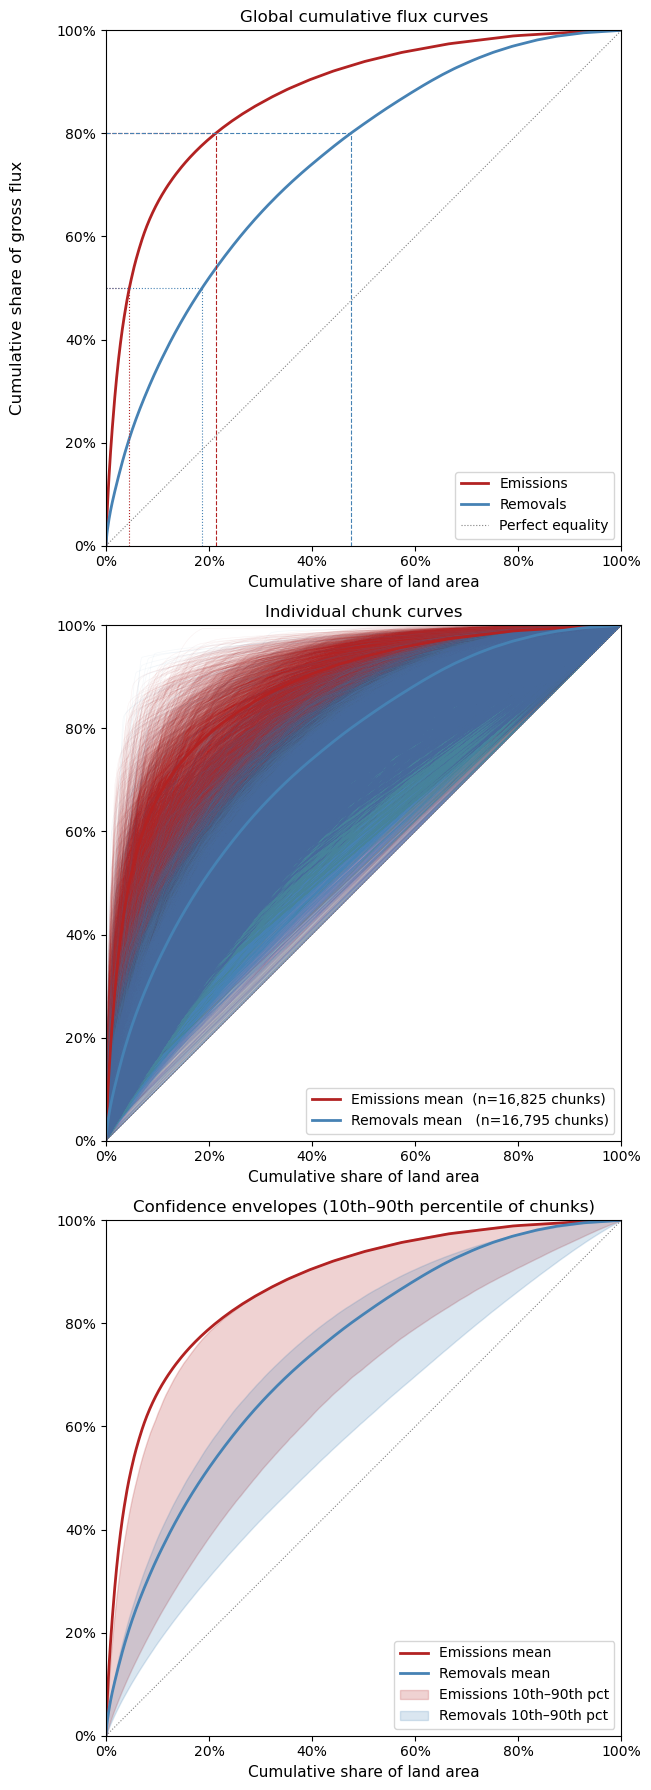

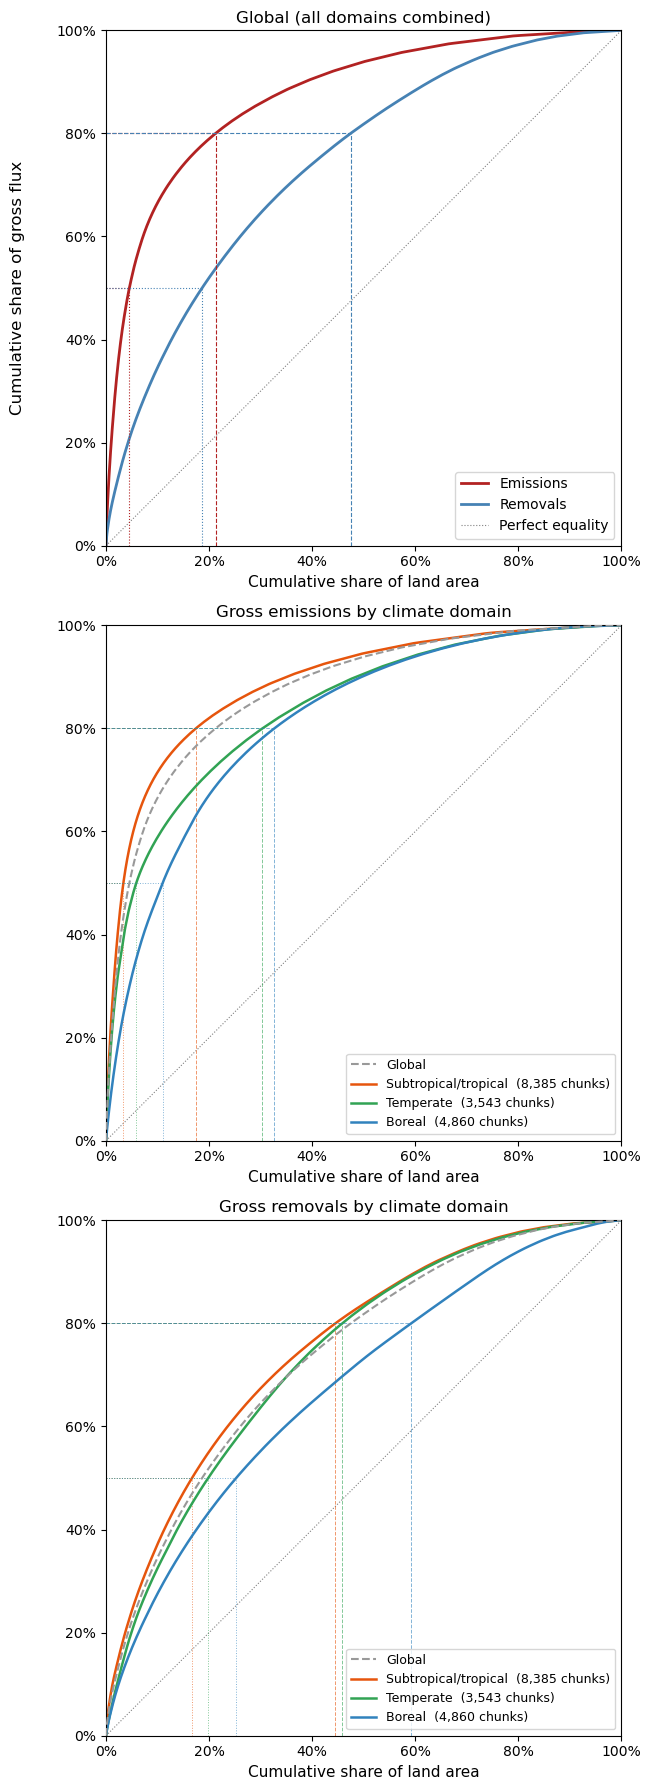

Chunks OK:          16,919
Chunks only NoData: 1,913  (expected — ice/ocean/remote islands)
Chunks missing:     0  (errors)
94 emis-skipped  |  124 remv-skipped
Area:   emis=5,728.0 Mha  remv=7,048.9 Mha
Flux:   emis=20.40999 GtCO2e/yr  remv=23.96266 GtCO2/yr
Gini:   emis=0.7474  remv=0.4818

Chunks by climate domain:
  Subtropical/tropical        8,385 chunks
  Temperate                   3,543 chunks
  Boreal                      4,860 chunks
  Unassigned                    131 chunks

  Flux %  Emis area %  Emis area (Mha)  Emis flux (GtCO2e)  Remv area %  Remv area (Mha)  Remv flux (GtCO2e)
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────
     10%         0.4%            22.59             2.04100         1.6%           111.29             2.39627
     25%         1.4%            79.78             5.10250         6.0%           421.57             5.99067
     50%         4.5%           259.43            10.20500        18.6%

In [7]:
### Makes figures and validation tables

def lorenz_from_histogram(bin_area, bin_flux):
    occupied = (bin_area > 0) | (bin_flux > 0)
    if not occupied.any():
        return None, None
    cum_area = np.concatenate([[0.0], np.cumsum(bin_area[occupied][::-1])])
    cum_flux = np.concatenate([[0.0], np.cumsum(bin_flux[occupied][::-1])])
    if cum_area[-1] == 0 or cum_flux[-1] == 0:
        return None, None
    return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

def gini(x, y):
    return 2.0 * np.trapezoid(y, x) - 1.0

emis_x, emis_y = lorenz_from_histogram(emis_bin_area, emis_bin_flux)
remv_x, remv_y = lorenz_from_histogram(remv_bin_area, remv_bin_flux)

emis_area_Mha = emis_bin_area.sum() / 1e6
remv_area_Mha = remv_bin_area.sum() / 1e6
emis_flux_Gt  = emis_bin_flux.sum() / 1e9
remv_flux_Gt  = remv_bin_flux.sum() / 1e9
area_label    = f"Global_{PERIOD}"

domain_curves = {}
for d in DOMAINS:
    ex, ey = lorenz_from_histogram(domain_emis_bin_area[d], domain_emis_bin_flux[d])
    rx, ry = lorenz_from_histogram(domain_remv_bin_area[d], domain_remv_bin_flux[d])
    if ex is not None or rx is not None:
        domain_curves[d] = {
            'emis_x': ex, 'emis_y': ey, 'remv_x': rx, 'remv_y': ry,
            'emis_area_Mha': domain_emis_bin_area[d].sum() / 1e6,
            'remv_area_Mha': domain_remv_bin_area[d].sum() / 1e6,
            'emis_flux_Gt' : domain_emis_bin_flux[d].sum() / 1e9,
            'remv_flux_Gt' : domain_remv_bin_flux[d].sum() / 1e9,
        }

pct_fmt = plt.FuncFormatter(lambda v, _: f'{100*v:.0f}%')
x_c     = np.linspace(0, 1, N_PLOT_POINTS)


# ── Figure 1: Global curves (3 panels) ──────────────────────────────────────
fig1, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 18))

# Panel 1 — global mean + reference lines
ax1.plot(emis_x, emis_y, color='firebrick', lw=2,
         label=f'Emissions') # (Gini={gini(emis_x, emis_y):.3f})')
ax1.plot(remv_x, remv_y, color='steelblue', lw=2,
         label=f'Removals') #  (Gini={gini(remv_x, remv_y):.3f})')
ax1.plot([0,1],[0,1], color='gray', lw=0.8, ls=':', label='Perfect equality')
ax1.set_xlim(0,1); ax1.set_ylim(0,1); ax1.set_box_aspect(1)
ax1.set_xlabel('Cumulative share of land area', fontsize=11)
ax1.set_title('Global cumulative flux curves', fontsize=12)
ax1.legend(loc='lower right', fontsize=10)
ax1.xaxis.set_major_formatter(pct_fmt); ax1.yaxis.set_major_formatter(pct_fmt)
for target, ls in [(0.80, '--'), (0.50, ':')]:
    for x_at, col in [(np.interp(target, emis_y, emis_x), 'firebrick'),
                      (np.interp(target, remv_y, remv_x), 'steelblue')]:
        ax1.axvline(x=x_at, ymin=0, ymax=target, color=col, lw=0.8, ls=ls)
        ax1.axhline(y=target, xmin=0, xmax=x_at,  color=col, lw=0.8, ls=ls)

# Panel 2 — individual chunk curves (both) + mean curves
if chunk_emis_curves:
    ax2.add_collection(LineCollection(
        [np.column_stack(c) for c in chunk_emis_curves],
        colors='firebrick', alpha=INDIVIDUAL_ALPHA, lw=0.5, zorder=1))
if chunk_remv_curves:
    ax2.add_collection(LineCollection(
        [np.column_stack(c) for c in chunk_remv_curves],
        colors='steelblue', alpha=INDIVIDUAL_ALPHA, lw=0.5, zorder=1))
ax2.plot(emis_x, emis_y, color='firebrick', lw=2, zorder=2,
         label=f'Emissions mean  (n={len(chunk_emis_curves):,} chunks)')
ax2.plot(remv_x, remv_y, color='steelblue', lw=2, zorder=2,
         label=f'Removals mean   (n={len(chunk_remv_curves):,} chunks)')
ax2.plot([0,1],[0,1], color='gray', lw=0.8, ls=':')
ax2.set_xlim(0,1); ax2.set_ylim(0,1); ax2.set_box_aspect(1)
ax2.set_xlabel('Cumulative share of land area', fontsize=11)
ax2.set_title('Individual chunk curves', fontsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.xaxis.set_major_formatter(pct_fmt); ax2.yaxis.set_major_formatter(pct_fmt)

# Panel 3 — mean curves + 10th–90th percentile envelopes
ax3.plot(emis_x, emis_y, color='firebrick', lw=2, label='Emissions mean')
ax3.plot(remv_x, remv_y, color='steelblue', lw=2, label='Removals mean')
ax3.plot([0,1],[0,1], color='gray', lw=0.8, ls=':')
if len(chunk_emis_curves) >= 10:
    emat = np.vstack([np.interp(x_c, cx, cy) for cx, cy in chunk_emis_curves])
    ax3.fill_between(x_c, np.percentile(emat, 10, axis=0),
                     np.percentile(emat, 90, axis=0),
                     color='firebrick', alpha=0.2, label='Emissions 10th–90th pct')
if len(chunk_remv_curves) >= 10:
    rmat = np.vstack([np.interp(x_c, cx, cy) for cx, cy in chunk_remv_curves])
    ax3.fill_between(x_c, np.percentile(rmat, 10, axis=0),
                     np.percentile(rmat, 90, axis=0),
                     color='steelblue', alpha=0.2, label='Removals 10th–90th pct')
ax3.set_xlim(0,1); ax3.set_ylim(0,1); ax3.set_box_aspect(1)
ax3.set_xlabel('Cumulative share of land area', fontsize=11)
ax3.set_title('Confidence envelopes (10th–90th percentile of chunks)', fontsize=12)
ax3.legend(loc='lower right', fontsize=10)
ax3.xaxis.set_major_formatter(pct_fmt); ax3.yaxis.set_major_formatter(pct_fmt)

plt.tight_layout()
pos1 = ax1.get_position()
fig1.text(pos1.x0 - 0.12, (pos1.y0 + pos1.y1) / 2,
          'Cumulative share of gross flux', fontsize=12, va='center', rotation='vertical')
plt.show()


# ── Figure 2: Climate domain breakdown (3 panels) ───────────────────────────
DOMAINS_PLOT = [d for d in DOMAINS if d != 'Unassigned']

fig2, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(8, 18))

# Panel 1 (top) — global combined
ax_top.plot(emis_x, emis_y, color='firebrick', lw=2, label='Emissions')
ax_top.plot(remv_x, remv_y, color='steelblue', lw=2, label='Removals')
ax_top.plot([0,1],[0,1], color='gray', lw=0.8, ls=':', label='Perfect equality')
ax_top.set_xlim(0,1); ax_top.set_ylim(0,1); ax_top.set_box_aspect(1)
ax_top.set_xlabel('Cumulative share of land area', fontsize=11)
ax_top.set_title('Global (all domains combined)', fontsize=12)
ax_top.legend(loc='lower right', fontsize=10)
ax_top.xaxis.set_major_formatter(pct_fmt); ax_top.yaxis.set_major_formatter(pct_fmt)
for target, ls in [(0.80, '--'), (0.50, ':')]:
    for x_at, col in [(np.interp(target, emis_y, emis_x), 'firebrick'),
                      (np.interp(target, remv_y, remv_x), 'steelblue')]:
        ax_top.axvline(x=x_at, ymin=0, ymax=target, color=col, lw=0.8, ls=ls)
        ax_top.axhline(y=target, xmin=0, xmax=x_at,  color=col, lw=0.8, ls=ls)

# Panel 2 (mid) — emissions by domain
ax_mid.plot(emis_x, emis_y, color='#999999', lw=1.5, ls='--', label='Global', zorder=10)
ax_mid.plot([0,1],[0,1], color='gray', lw=0.8, ls=':')
for d in DOMAINS_PLOT:
    if d in domain_curves and domain_curves[d]['emis_x'] is not None:
        dc  = domain_curves[d]
        col = DOMAIN_COLORS[d]
        lbl = f"{d}  ({n_ok_domain[d]:,} chunks)"
        ax_mid.plot(dc['emis_x'], dc['emis_y'], color=col, lw=1.8, label=lbl)
        for target, ls in [(0.80, '--'), (0.50, ':')]:
            x_at = np.interp(target, dc['emis_y'], dc['emis_x'])
            ax_mid.axvline(x=x_at, ymin=0, ymax=target, color=col, lw=0.7, ls=ls, alpha=0.6)
            ax_mid.axhline(y=target, xmin=0, xmax=x_at,  color=col, lw=0.7, ls=ls, alpha=0.6)
ax_mid.set_xlim(0,1); ax_mid.set_ylim(0,1); ax_mid.set_box_aspect(1)
ax_mid.set_xlabel('Cumulative share of land area', fontsize=11)
ax_mid.set_title('Gross emissions by climate domain', fontsize=12)
ax_mid.legend(loc='lower right', fontsize=9)
ax_mid.xaxis.set_major_formatter(pct_fmt); ax_mid.yaxis.set_major_formatter(pct_fmt)

# Panel 3 (bot) — removals by domain
ax_bot.plot(remv_x, remv_y, color='#999999', lw=1.5, ls='--', label='Global', zorder=10)
ax_bot.plot([0,1],[0,1], color='gray', lw=0.8, ls=':')
for d in DOMAINS_PLOT:
    if d in domain_curves and domain_curves[d]['remv_x'] is not None:
        dc  = domain_curves[d]
        col = DOMAIN_COLORS[d]
        lbl = f"{d}  ({n_ok_domain[d]:,} chunks)"
        ax_bot.plot(dc['remv_x'], dc['remv_y'], color=col, lw=1.8, label=lbl)
        for target, ls in [(0.80, '--'), (0.50, ':')]:
            x_at = np.interp(target, dc['remv_y'], dc['remv_x'])
            ax_bot.axvline(x=x_at, ymin=0, ymax=target, color=col, lw=0.7, ls=ls, alpha=0.6)
            ax_bot.axhline(y=target, xmin=0, xmax=x_at,  color=col, lw=0.7, ls=ls, alpha=0.6)
ax_bot.set_xlim(0,1); ax_bot.set_ylim(0,1); ax_bot.set_box_aspect(1)
ax_bot.set_xlabel('Cumulative share of land area', fontsize=11)
ax_bot.set_title('Gross removals by climate domain', fontsize=12)
ax_bot.legend(loc='lower right', fontsize=9)
ax_bot.xaxis.set_major_formatter(pct_fmt); ax_bot.yaxis.set_major_formatter(pct_fmt)

plt.tight_layout()
pos_top = ax_top.get_position()
fig2.text(pos_top.x0 - 0.12, (pos_top.y0 + pos_top.y1) / 2,
          'Cumulative share of gross flux', fontsize=12, va='center', rotation='vertical')
plt.show()


# ── Validation ───────────────────────────────────────────────────────────────
print(f"Chunks OK:          {n_ok:,}")
print(f"Chunks only NoData: {n_no_data:,}  (expected — ice/ocean/remote islands)")
print(f"Chunks missing:     {n_missing:,}  (errors)")
print(f"{n_skipped_emis:,} emis-skipped  |  {n_skipped_remv:,} remv-skipped")
print(f"Area:   emis={emis_area_Mha:,.1f} Mha  remv={remv_area_Mha:,.1f} Mha")
print(f"Flux:   emis={emis_flux_Gt:.5f} GtCO2e/yr  remv={remv_flux_Gt:.5f} GtCO2/yr")
print(f"Gini:   emis={gini(emis_x, emis_y):.4f}  remv={gini(remv_x, remv_y):.4f}")
print(f"\nChunks by climate domain:")
for d in DOMAINS:
    print(f"  {d:<25}  {n_ok_domain[d]:>6,} chunks")
unmatched = n_ok - sum(n_ok_domain.values())
if unmatched:
    print(f"  {'(domain lookup misses)':25}  {unmatched:>6,}")

# ── Summary table ────────────────────────────────────────────────────────────
flux_pcts = [10, 25, 50, 75, 80, 90, 95, 100]
hdr = (f"  {'Flux %':>6}  {'Emis area %':>11}  {'Emis area (Mha)':>15}  "
       f"{'Emis flux (GtCO2e)':>18}  {'Remv area %':>11}  {'Remv area (Mha)':>15}  "
       f"{'Remv flux (GtCO2e)':>18}")
print("\n" + hdr)
print("  " + "─" * (len(hdr) - 2))
for fp in flux_pcts:
    frac = fp / 100
    ex_  = np.interp(frac, emis_y, emis_x)
    rx_  = np.interp(frac, remv_y, remv_x)
    print(f"  {fp:>5}%  {100*ex_:>10.1f}%  {ex_*emis_area_Mha:>15.2f}  "
          f"{frac*emis_flux_Gt:>18.5f}  "
          f"{100*rx_:>10.1f}%  {rx_*remv_area_Mha:>15.2f}  "
          f"{frac*remv_flux_Gt:>18.5f}")

# ── Detailed curve CSV ───────────────────────────────────────────────────────
def _interp_safe(x_fine, cx, cy):
    if cx is None:
        return np.full(len(x_fine), np.nan)
    return np.interp(x_fine, cx, cy)

x_fine = np.linspace(0, 1, 1001)

csv_cols = {
    'cum_area_frac'              : x_fine,
    'emis_cum_flux_frac_global'  : _interp_safe(x_fine, emis_x, emis_y),
    'remv_cum_flux_frac_global'  : _interp_safe(x_fine, remv_x, remv_y),
    'emis_cum_flux_GtCO2e_global': _interp_safe(x_fine, emis_x, emis_y) * emis_flux_Gt,
    'remv_cum_flux_GtCO2e_global': _interp_safe(x_fine, remv_x, remv_y) * remv_flux_Gt,
    'emis_cum_area_Mha_global'   : x_fine * emis_area_Mha,
    'remv_cum_area_Mha_global'   : x_fine * remv_area_Mha,
}
for d in DOMAINS:
    k  = d.replace("/", "_").replace(" ", "_")
    dc = domain_curves.get(d, {})
    csv_cols[f'emis_cum_flux_frac_{k}']    = _interp_safe(x_fine, dc.get('emis_x'), dc.get('emis_y'))
    csv_cols[f'remv_cum_flux_frac_{k}']    = _interp_safe(x_fine, dc.get('remv_x'), dc.get('remv_y'))
    csv_cols[f'emis_cum_flux_GtCO2e_{k}']  = csv_cols[f'emis_cum_flux_frac_{k}'] * dc.get('emis_flux_Gt', np.nan)
    csv_cols[f'remv_cum_flux_GtCO2e_{k}']  = csv_cols[f'remv_cum_flux_frac_{k}'] * dc.get('remv_flux_Gt', np.nan)
    csv_cols[f'emis_cum_area_Mha_{k}']     = x_fine * dc.get('emis_area_Mha', np.nan)
    csv_cols[f'remv_cum_area_Mha_{k}']     = x_fine * dc.get('remv_area_Mha', np.nan)

curve_df  = pd.DataFrame(csv_cols)
csv_path  = f"{LULUCF_zonal_stats_folder}/lorenz_curves__{area_label}.csv"
meta_path = csv_path.replace('.csv', '__meta.csv')
curve_df.to_csv(csv_path, index=False, float_format='%.8f')

meta = {
    'area_label': area_label, 'period': PERIOD,
    'n_chunks_ok': n_ok, 'n_chunks_missing': n_missing,
    'emis_total_Mha': emis_area_Mha, 'remv_total_Mha': remv_area_Mha,
    'emis_total_GtCO2e': emis_flux_Gt, 'remv_total_GtCO2e': remv_flux_Gt,
    'gini_emis_global': gini(emis_x, emis_y),
    'gini_remv_global': gini(remv_x, remv_y),
    **{f'n_chunks_{d.replace("/","_").replace(" ","_")}': n_ok_domain[d] for d in DOMAINS},
    **{f'gini_emis_{d.replace("/","_").replace(" ","_")}':
       gini(domain_curves[d]['emis_x'], domain_curves[d]['emis_y'])
       if d in domain_curves and domain_curves[d]['emis_x'] is not None else np.nan
       for d in DOMAINS},
    **{f'gini_remv_{d.replace("/","_").replace(" ","_")}':
       gini(domain_curves[d]['remv_x'], domain_curves[d]['remv_y'])
       if d in domain_curves and domain_curves[d]['remv_x'] is not None else np.nan
       for d in DOMAINS},
    **{f'emis_total_Mha_{d.replace("/","_").replace(" ","_")}':
       domain_curves[d]['emis_area_Mha'] if d in domain_curves else np.nan for d in DOMAINS},
    **{f'remv_total_Mha_{d.replace("/","_").replace(" ","_")}':
       domain_curves[d]['remv_area_Mha'] if d in domain_curves else np.nan for d in DOMAINS},
    **{f'emis_total_GtCO2e_{d.replace("/","_").replace(" ","_")}':
       domain_curves[d]['emis_flux_Gt'] if d in domain_curves else np.nan for d in DOMAINS},
    **{f'remv_total_GtCO2e_{d.replace("/","_").replace(" ","_")}':
       domain_curves[d]['remv_flux_Gt'] if d in domain_curves else np.nan for d in DOMAINS},
}
pd.Series(meta).to_csv(meta_path, header=False)

print(f"\nSaved: {csv_path}  ({len(curve_df):,} rows × {len(curve_df.columns)} cols)")
print(f"Saved: {meta_path}")